In [1]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score, roc_auc_score, accuracy_score

In [2]:
#Importing dataset
data = pd.read_csv('Nigeria.csv')
print("Dataframe shape:", data.shape)
data.head(10)

Dataframe shape: (2250, 11)


,State,Latitude,Longitude,Temperature,Humidity,Soil_Moisture,Rainfall,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Disease_Class
0,Ogun,5.554835,8.658020,27.66,73.40,47.46,259.64,52.60,17.15,58.42,Fungal Blight
1,Ogun,7.534859,6.567706,24.45,66.21,65.82,63.13,71.37,78.40,32.28,Healthy
2,Enugu,5.785578,5.090281,33.47,NaN,51.71,237.36,67.05,NaN,18.31,Healthy
3,Cross River,10.728663,8.797528,24.72,41.77,32.02,404.11,48.45,75.36,42.39,Healthy
4,Kaduna,6.356269,6.712313,35.87,75.41,49.28,194.64,90.94,71.41,34.68,Bacterial Wilt
5,Cross River,8.026734,5.968238,36.05,NaN,47.35,422.98,56.73,22.18,56.00,Viral Mosaic
6,Ogun,12.561073,8.335832,23.54,81.77,67.64,302.24,55.53,22.86,98.13,Viral Mosaic
7,Kebbi,6.338847,4.532769,31.05,88.73,78.72,423.66,NaN,77.98,21.19,Healthy
8,Cross River,9.070246,13.669076,21.58,80.10,38.77,352.87,92.99,74.91,43.55,Viral Mosaic
9,Kaduna,8.273445,12.978574,27.05,91.03,63.44,91.37,NaN,44.02,93.88,Bacterial Wilt


Data types: State                   str
Latitude            float64
Longitude           float64
Temperature         float64
Humidity            float64
Soil_Moisture       float64
Rainfall            float64
Nitrogen_Level      float64
Phosphorus_Level    float64
Potassium_Level     float64
Disease_Class           str
dtype: object

        Missing Values:       
State               140
Latitude            160
Longitude           139
Temperature         136
Humidity            128
Soil_Moisture       139
Rainfall            144
Nitrogen_Level      155
Phosphorus_Level    164
Potassium_Level     157
Disease_Class         0
dtype: int64


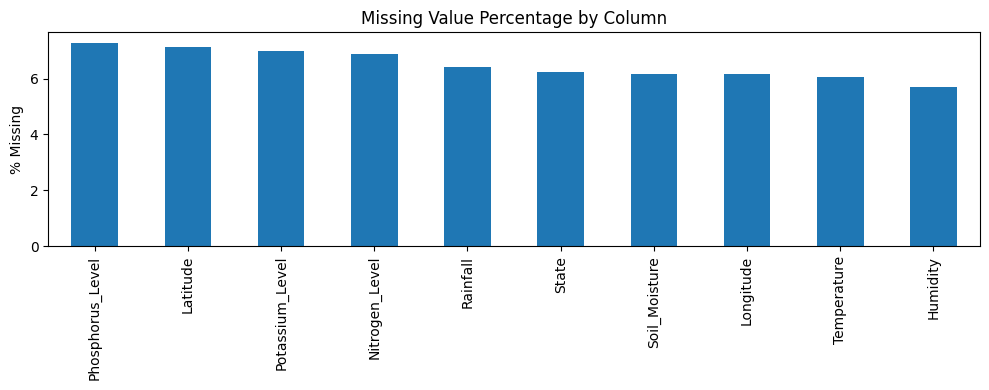

Phosphorus_Level    7.288889
Latitude            7.111111
Potassium_Level     6.977778
Nitrogen_Level      6.888889
Rainfall            6.400000
State               6.222222
Soil_Moisture       6.177778
Longitude           6.177778
Temperature         6.044444
Humidity            5.688889
dtype: float64


In [3]:
#Checking the data types of each column
print("Data types:", data.dtypes)
#Checking for missing values in the dataset
print("\n        Missing Values:       ")
print(data.isnull().sum())

missing_pct = data.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 4))
missing_pct.plot(kind='bar')
plt.title('Missing Value Percentage by Column')
plt.ylabel('% Missing')
plt.tight_layout()
plt.show()
print(missing_pct)

In [4]:
data['State'].mode()

0    Cross River
Name: State, dtype: str

Disease_Class
Healthy                788
Fungal Blight          562
Bacterial Wilt         338
Viral Mosaic           337
Nutrient Deficiency    225
Name: count, dtype: int64


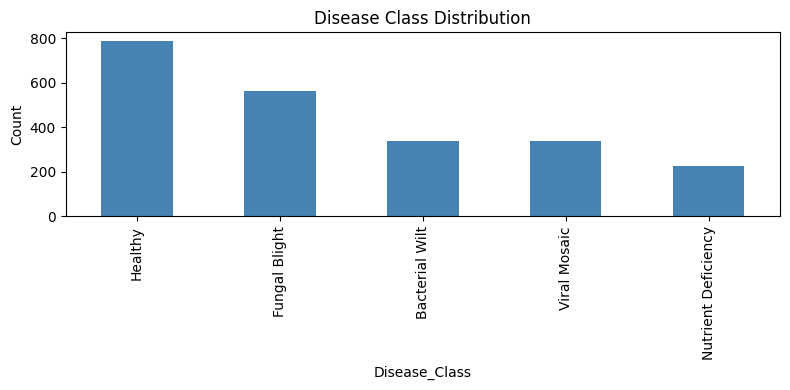

Imbalance ratio (max/min): 3.5


In [5]:
#Checking the distribution of the target variable 'Disease_Class'
print(data['Disease_Class'].value_counts())

#Visualizing the distribution of the target variable
plt.figure(figsize=(8, 4))
data['Disease_Class'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Disease Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
imbalance_ratio = data['Disease_Class'].value_counts().max() / data['Disease_Class'].value_counts().min()
print("Imbalance ratio (max/min):", round(imbalance_ratio, 2))


In [6]:
#Creating a list of the numerical columns in the dataset
num_cols = data.select_dtypes(include=np.number).columns

In [7]:
#Filling missing values with mode for categorical columns
data['State'] = data['State'].fillna(data['State'].mode()[0])

In [8]:
#Filling missing values with median for numerical columns
missing_cols = num_cols
for col in missing_cols:
    data[col] = data[col].fillna(data[col].median())
print("\nMissing values filled with median for numerical columns.")
print(data.isnull().sum())


Missing values filled with median for numerical columns.
State               0
Latitude            0
Longitude           0
Temperature         0
Humidity            0
Soil_Moisture       0
Rainfall            0
Nitrogen_Level      0
Phosphorus_Level    0
Potassium_Level     0
Disease_Class       0
dtype: int64


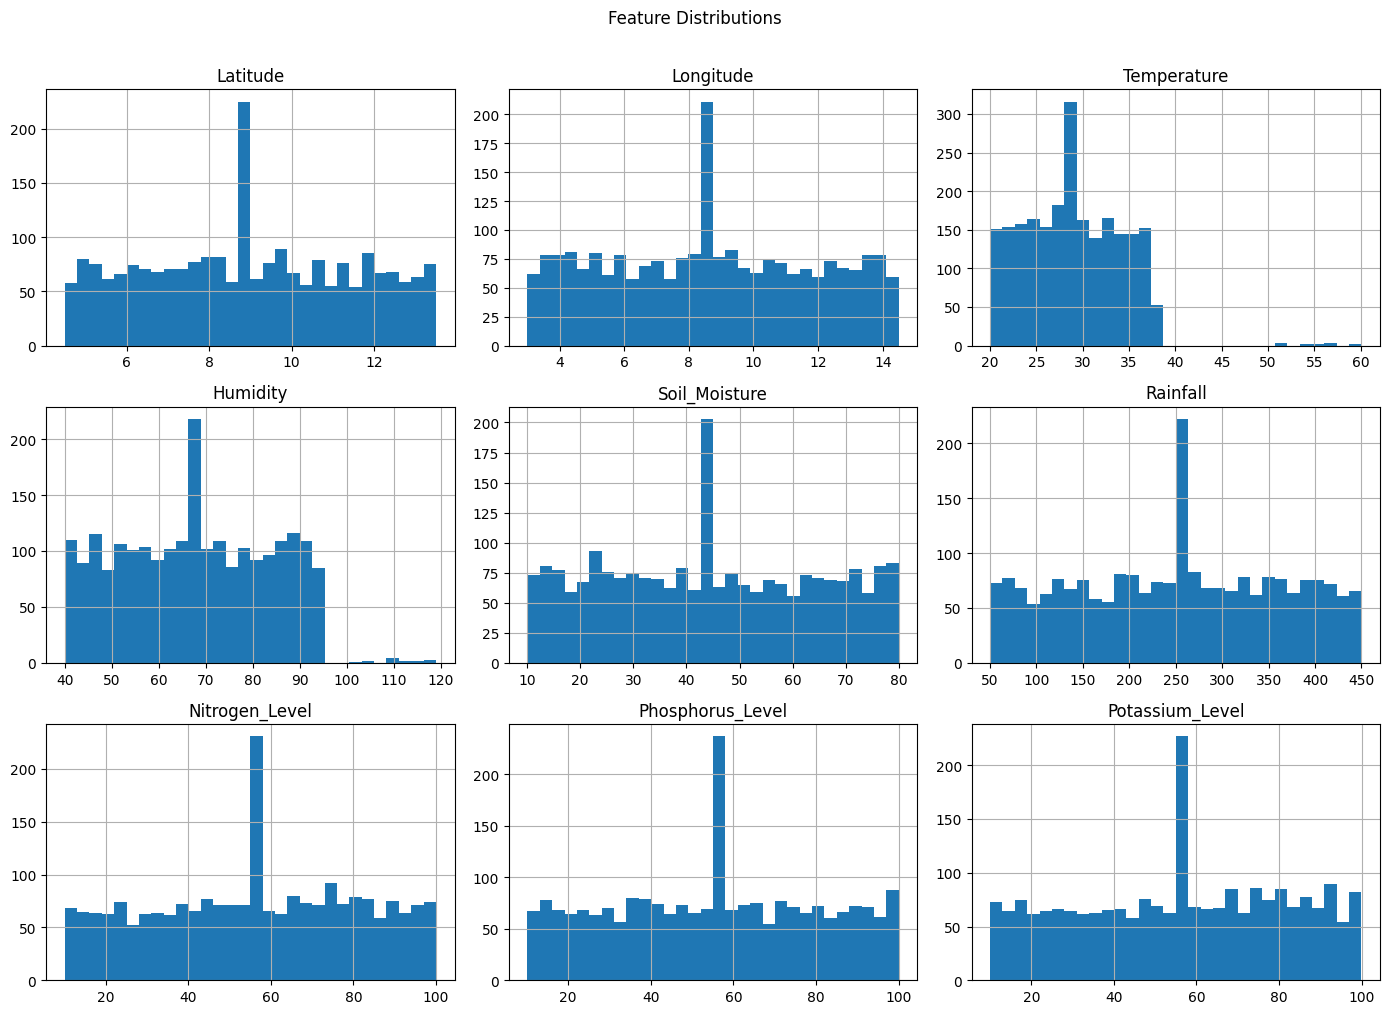

In [9]:
data[num_cols].hist(figsize=(14, 10), bins=30)
plt.suptitle('Feature Distributions', y=1.01)
plt.tight_layout()
plt.show()

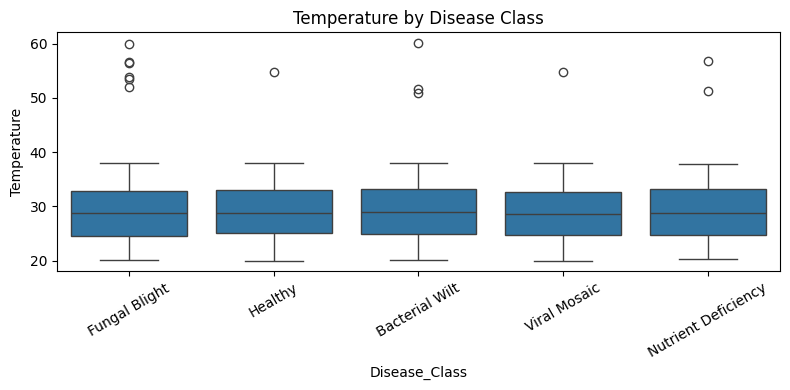

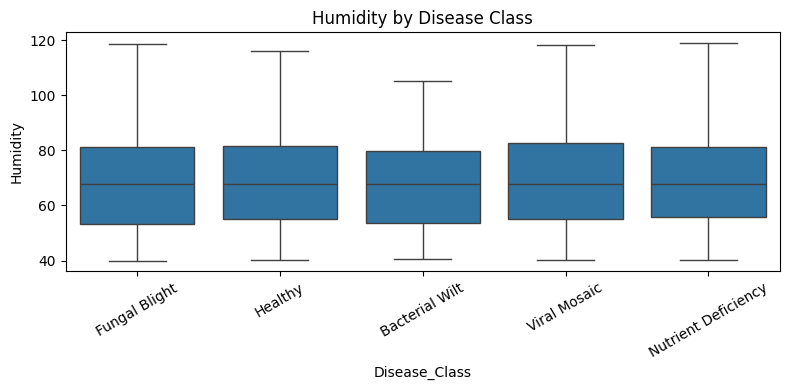

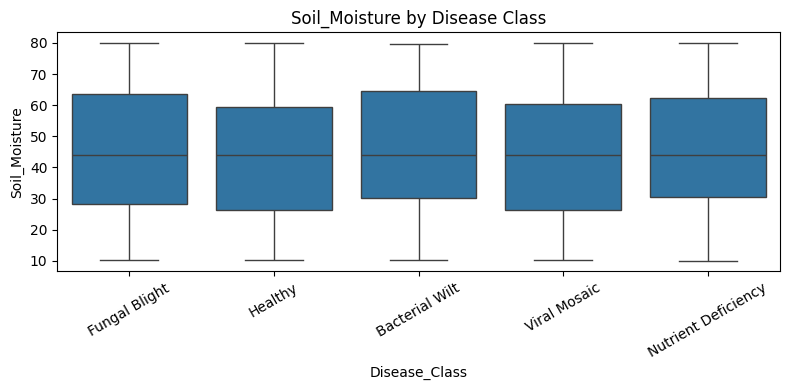

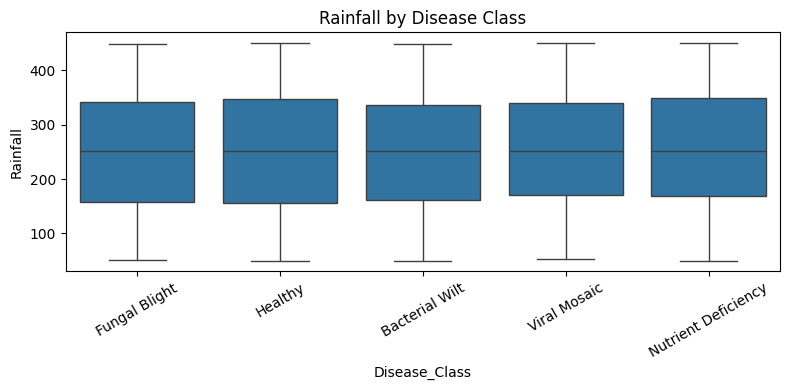

In [10]:
#Visualizing the relationship between features and the target variable using boxplots (Bivariate analysis)
for feat in ['Temperature', 'Humidity',	'Soil_Moisture', 'Rainfall']:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='Disease_Class', y=feat, data=data)
    plt.title(f'{feat} by Disease Class')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

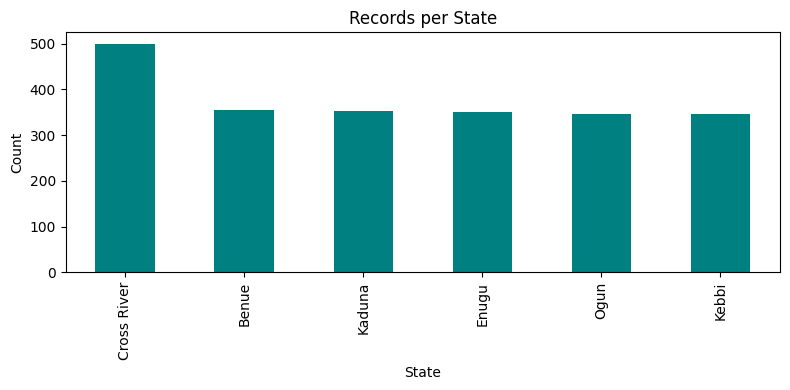

State
Cross River    500
Benue          355
Kaduna         352
Enugu          350
Ogun           347
Kebbi          346
Name: count, dtype: int64


In [11]:
plt.figure(figsize=(8, 4))
data['State'].value_counts().plot(kind='bar', color='teal')
plt.title('Records per State')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print(data['State'].value_counts())

In [12]:
#Encoding the target variable 'Disease_Class' using LabelEncoder
le = LabelEncoder()
data['Disease_Class_Encoded'] = le.fit_transform(data['Disease_Class'])
print(data['Disease_Class_Encoded'].value_counts())

Disease_Class_Encoded
2    788
1    562
0    338
4    337
3    225
Name: count, dtype: int64


In [13]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print(mapping)

{'Bacterial Wilt': np.int64(0), 'Fungal Blight': np.int64(1), 'Healthy': np.int64(2), 'Nutrient Deficiency': np.int64(3), 'Viral Mosaic': np.int64(4)}


In [14]:
data.head()

,State,Latitude,Longitude,Temperature,Humidity,Soil_Moisture,Rainfall,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Disease_Class,Disease_Class_Encoded
0,Ogun,5.554835,8.658020,27.66,73.40,47.46,259.64,52.60,17.15,58.42,Fungal Blight,1
1,Ogun,7.534859,6.567706,24.45,66.21,65.82,63.13,71.37,78.40,32.28,Healthy,2
2,Enugu,5.785578,5.090281,33.47,67.81,51.71,237.36,67.05,55.20,18.31,Healthy,2
3,Cross River,10.728663,8.797528,24.72,41.77,32.02,404.11,48.45,75.36,42.39,Healthy,2
4,Kaduna,6.356269,6.712313,35.87,75.41,49.28,194.64,90.94,71.41,34.68,Bacterial Wilt,0


In [15]:
def assign_region(lat):
    if lat >= 10:
        return 'North'
    elif lat >= 7:
        return 'Middle Belt'
    else:
        return 'South'

data['Region'] = data['Latitude'].apply(assign_region)
print(data['Region'].value_counts())
data.head()
#data = pd.get_dummies(data, columns=['Region'], drop_first=False)

#region_cols = [col for col in data.columns if col.startswith('Region_')]
#features = num_cols + state_cols + region_cols

Region
Middle Belt    894
North          779
South          577
Name: count, dtype: int64


,State,Latitude,Longitude,Temperature,Humidity,Soil_Moisture,Rainfall,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Disease_Class,Disease_Class_Encoded,Region
0,Ogun,5.554835,8.658020,27.66,73.40,47.46,259.64,52.60,17.15,58.42,Fungal Blight,1,South
1,Ogun,7.534859,6.567706,24.45,66.21,65.82,63.13,71.37,78.40,32.28,Healthy,2,Middle Belt
2,Enugu,5.785578,5.090281,33.47,67.81,51.71,237.36,67.05,55.20,18.31,Healthy,2,South
3,Cross River,10.728663,8.797528,24.72,41.77,32.02,404.11,48.45,75.36,42.39,Healthy,2,North
4,Kaduna,6.356269,6.712313,35.87,75.41,49.28,194.64,90.94,71.41,34.68,Bacterial Wilt,0,South


In [16]:
#Drop the first category to avoid multicollinearity
data = pd.get_dummies(data, columns=['Region'], drop_first=False, dtype=int)
data.tail()

,State,Latitude,Longitude,Temperature,Humidity,Soil_Moisture,Rainfall,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Disease_Class,Disease_Class_Encoded,Region_Middle Belt,Region_North,Region_South
2245,Kaduna,9.623745,6.480364,27.15,51.52,34.22,367.86,44.80,26.66,83.52,Bacterial Wilt,0,1,0,0
2246,Kebbi,10.185502,10.617276,23.91,93.35,41.58,123.19,82.26,24.70,52.91,Fungal Blight,1,0,1,0
2247,Benue,9.168731,4.820255,26.73,76.73,62.40,373.25,44.79,81.00,80.55,Fungal Blight,1,1,0,0
2248,Ogun,4.960490,10.913353,25.99,82.82,73.16,294.80,28.42,10.54,93.72,Fungal Blight,1,0,0,1
2249,Enugu,6.595727,4.474163,23.17,67.81,13.48,127.29,15.85,55.20,75.91,Fungal Blight,1,0,0,1


In [17]:
df = data.drop(columns=['State', 'Latitude', 'Longitude', 'Disease_Class'])

In [18]:
df.head()

,Temperature,Humidity,Soil_Moisture,Rainfall,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Disease_Class_Encoded,Region_Middle Belt,Region_North,Region_South
0,27.66,73.40,47.46,259.64,52.60,17.15,58.42,1,0,0,1
1,24.45,66.21,65.82,63.13,71.37,78.40,32.28,2,1,0,0
2,33.47,67.81,51.71,237.36,67.05,55.20,18.31,2,0,0,1
3,24.72,41.77,32.02,404.11,48.45,75.36,42.39,2,0,1,0
4,35.87,75.41,49.28,194.64,90.94,71.41,34.68,0,0,0,1


In [19]:
#Getting the summary statistics of the dataset from the float and int columns (the numerical columns)
df.describe()

,Temperature,Humidity,Soil_Moisture,Rainfall,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Disease_Class_Encoded,Region_Middle Belt,Region_North,Region_South
count,2250.00000,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000
mean,28.98564,67.924822,44.637787,250.952022,56.175960,55.235724,56.369680,1.849333,0.397333,0.346222,0.256444
std,5.28983,15.893161,19.995792,110.709136,24.778593,25.065163,25.178599,1.236024,0.489455,0.475871,0.436767
min,20.00000,40.010000,10.080000,50.100000,10.060000,10.190000,10.000000,0.000000,0.000000,0.000000,0.000000
25%,24.85250,54.695000,27.532500,158.655000,36.505000,35.160000,35.682500,1.000000,0.000000,0.000000,0.000000
50%,28.80000,67.810000,44.090000,252.265000,56.570000,55.200000,57.300000,2.000000,0.000000,0.000000,0.000000
75%,32.93750,81.482500,62.152500,343.840000,76.250000,75.375000,77.187500,2.000000,1.000000,1.000000,1.000000
max,60.07000,118.940000,79.920000,449.970000,99.990000,99.990000,99.970000,4.000000,1.000000,1.000000,1.000000


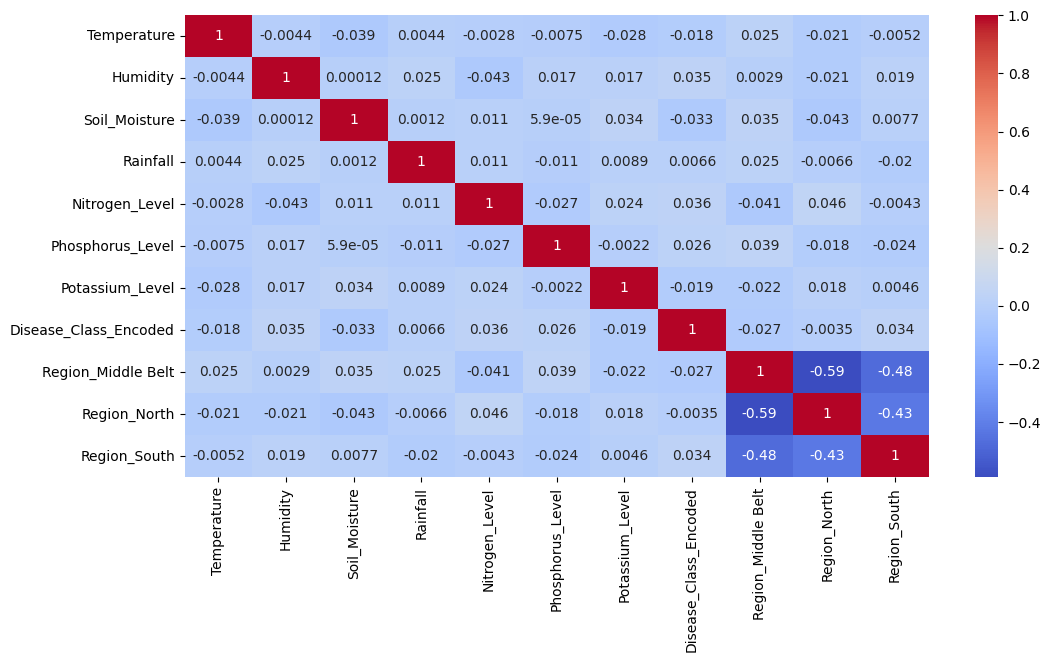

In [20]:
#Correlation heatmap to visualize relationships between numerical features
corr_matrix = df.corr()
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [21]:
outlier_report = []
num_cols = df.select_dtypes(include=['number']).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count how many rows fall outside the boundaries
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_pct = (outlier_count / df.shape[0]) * 100
    
    outlier_report.append({
        'Column': col,
        'Outlier Count': outlier_count,
        'Percentage (%)': round(outlier_pct, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2)
    })

# Convert the results into a clean, scannable DataFrame
report_df = pd.DataFrame(outlier_report)
print(report_df.to_string(index=False))

               Column  Outlier Count  Percentage (%)  Lower Bound  Upper Bound
          Temperature             13            0.58        12.72        45.06
             Humidity              0            0.00        14.51       121.66
        Soil_Moisture              0            0.00       -24.40       114.08
             Rainfall              0            0.00      -119.12       621.62
       Nitrogen_Level              0            0.00       -23.11       135.87
     Phosphorus_Level              0            0.00       -25.16       135.70
      Potassium_Level              0            0.00       -26.58       139.44
Disease_Class_Encoded            337           14.98        -0.50         3.50
   Region_Middle Belt              0            0.00        -1.50         2.50
         Region_North              0            0.00        -1.50         2.50
         Region_South              0            0.00        -1.50         2.50


In [25]:
x = df.drop(columns=['Disease_Class_Encoded']).values
y = df['Disease_Class_Encoded'].values

In [27]:
print(x)
print(y)

[[27.66 73.4  47.46 ...  0.    0.    1.  ]
 [24.45 66.21 65.82 ...  1.    0.    0.  ]
 [33.47 67.81 51.71 ...  0.    0.    1.  ]
 ...
 [26.73 76.73 62.4  ...  1.    0.    0.  ]
 [25.99 82.82 73.16 ...  0.    0.    1.  ]
 [23.17 67.81 13.48 ...  0.    0.    1.  ]]
[1 2 2 ... 1 1 1]


In [33]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)

Training set shape: (1800, 10)
Test set shape: (450, 10)
Training labels shape: (1800,)
Test labels shape: (450,)


In [34]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
print(x_scaled.shape)

(2250, 10)


In [35]:
#testing different k values for k-means, and storing the inertia values for each k
k_range = range(2, 11)
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    km.fit(x_scaled)
    inertias.append(km.inertia_)
    print(f'k={k:2d}, inertia: {km.inertia_:.2f}')

k= 2, inertia: 18938.96
k= 3, inertia: 15731.00
k= 4, inertia: 15032.05
k= 5, inertia: 14472.90
k= 6, inertia: 14013.29
k= 7, inertia: 13589.03
k= 8, inertia: 13155.69
k= 9, inertia: 12846.51
k=10, inertia: 12507.56


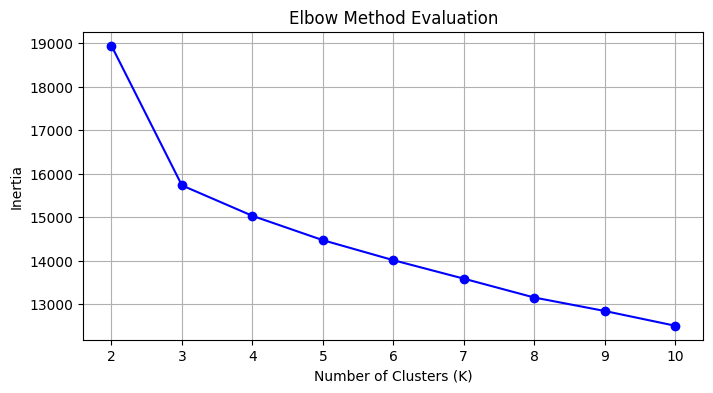

In [36]:
# Plotting the Elbow Curve to justify your final K choice
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker="o", color="b", linestyle="-")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method Evaluation")
plt.grid(True)
plt.xticks(k_range)
plt.savefig("elbow_method.png", dpi=150)
plt.show()

In [37]:
#Finding Optimal Number of Clusters using Silhouette Score
k_range = range(2, 11)
silhouette_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    labels = km.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    silhouette_scores.append(score)
    print(f'k={k:2d}, silhouette score: {score:.4f}')

#optimal K is the one with the highest silhouette score
best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print(f'Optimal K based on silhouette score: {best_k}')

k= 2, silhouette score: 0.1623
k= 3, silhouette score: 0.2335
k= 4, silhouette score: 0.1736
k= 5, silhouette score: 0.1339
k= 6, silhouette score: 0.1275
k= 7, silhouette score: 0.1035
k= 8, silhouette score: 0.1032
k= 9, silhouette score: 0.1050
k=10, silhouette score: 0.1030
Optimal K based on silhouette score: 3


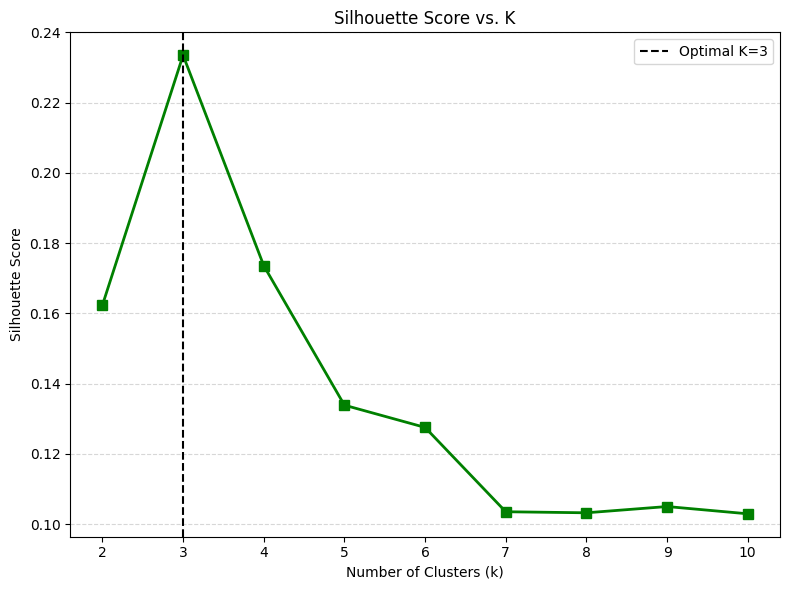

In [38]:
#Plotting Silhouette Scores for each K to visualize the optimal K choice
plt.figure(figsize=(8, 6))
plt.plot(k_range, silhouette_scores, marker='s', color='green', linewidth=2, markersize=7)
plt.axvline(best_k, color='black', linestyle='--', label=f'Optimal K={best_k}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score') 
plt.title('Silhouette Score vs. K')
plt.xticks(k_range)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('K-means_Silhouette.png', dpi=150)
plt.show()

In [39]:
#Set best_k from Step 1 (elbow) confirmed by Step 2 (silhouette)
best_k = 3

km_final = KMeans(n_clusters=best_k, init='k-means++', n_init=10, max_iter=300, tol=1e-4, random_state=42)
km_final.fit(x_scaled)
#Assigning cluster labels back to original dataframe
df['Cluster'] = km_final.labels_
print(f'Final K: {best_k}')
print(f'Final Inertia: {km_final.inertia_:.4f}')
print(f'Iteration taken: {km_final.n_iter_}')
print(f'\nCluster Counts:')
print(df['Cluster'].value_counts().sort_index())

Final K: 3
Final Inertia: 15730.9963
Iteration taken: 7

Cluster Counts:
Cluster
0    779
1    894
2    577
Name: count, dtype: int64


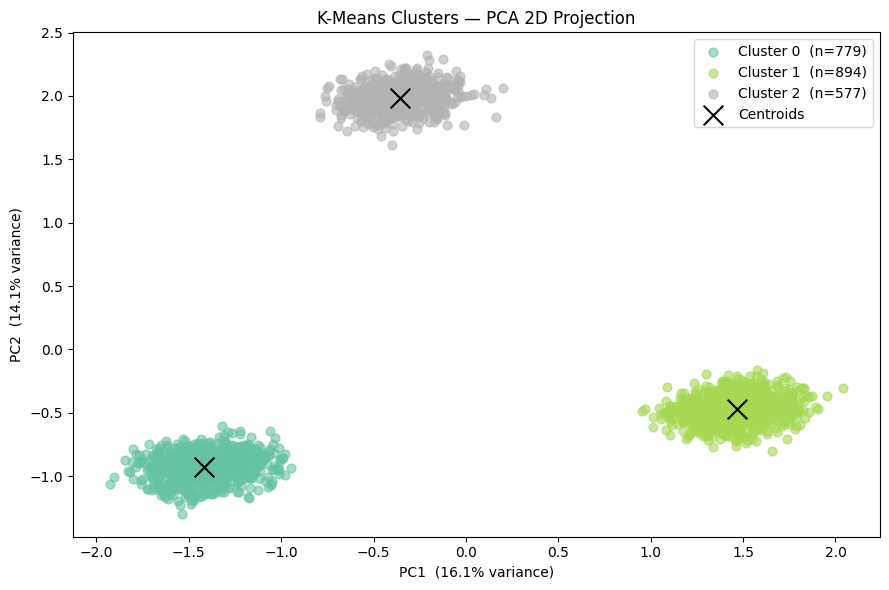

In [40]:
#Creating a 2D projection of the data using PCA for visualization
pca2 = PCA(n_components=2, random_state=42)
x_2d = pca2.fit_transform(x_scaled)
 
# Centroids in PCA space
centroids_2d = pca2.transform(km_final.cluster_centers_)
 
plt.figure(figsize=(9, 6))
palette = plt.colormaps['Set2'].resampled(best_k)
for c in range(best_k):
    mask = df['Cluster'] == c
    plt.scatter(x_2d[mask, 0], x_2d[mask, 1],
                color=palette(c), alpha=0.6, s=40,
                label=f'Cluster {c}  (n={mask.sum()})')
 
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            marker='x', s=200, c='black',
            zorder=5, label='Centroids')
plt.xlabel(f'PC1  ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2  ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title("K-Means Clusters — PCA 2D Projection")
plt.legend()
plt.tight_layout()
plt.savefig("kmeans_pca2d.png", dpi=150)
plt.show()


In [45]:
#Creating a Random Forest Classifier to predict failure_label using the original features.
rf = RandomForestClassifier(max_depth=10, min_samples_leaf=4, class_weight='balanced', random_state=42)
rf.fit(x_train, y_train)
#Predicting on the test set
y_pred = rf.predict(x_test)

In [46]:
#Evaluating the model on the test set
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
# Updated for Multiclass ROC AUC
print("ROC AUC Score:", roc_auc_score(y_test, rf.predict_proba(x_test), multi_class='ovr', average='macro'))


              precision    recall  f1-score   support

           0       0.13      0.15      0.14        68
           1       0.24      0.22      0.23       112
           2       0.33      0.35      0.34       158
           3       0.07      0.07      0.07        45
           4       0.18      0.16      0.17        67

    accuracy                           0.23       450
   macro avg       0.19      0.19      0.19       450
weighted avg       0.23      0.23      0.23       450

Accuracy: 0.2311111111111111
ROC AUC Score: 0.48791252089674797


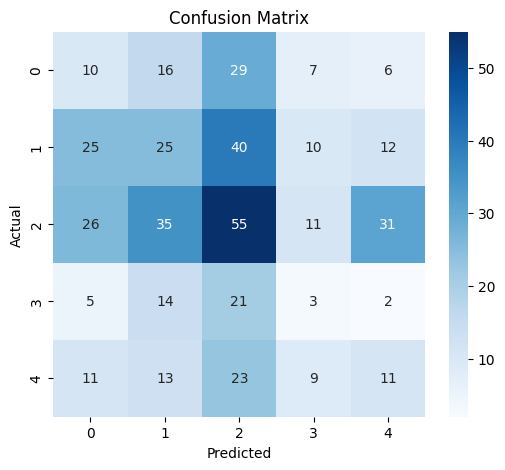

In [47]:
confusion_mtx = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()